# Notebook 12 — Explicabilidad con SHAP

**¿Por qué el modelo dijo que esto es un ataque?** Esta es la pregunta que un auditor o un operador de smart-grid hará la primera vez. Sin una respuesta clara, el detector es una caja negra — algo que en infraestructura crítica es inaceptable.

**SHAP (SHapley Additive exPlanations)** ofrece la respuesta correcta: por cada predicción, descompone la contribución de cada feature al score final. Tiene base teórica sólida (valores de Shapley de teoría de juegos) y proporciona tanto **explicación local** (por qué *este* punto fue señalado) como **global** (qué features importan en general).

**En este notebook:**
1. **Explicabilidad del LightGBM supervisado** (NB09) usando `TreeExplainer` (rápido, exacto en árboles).
2. **Explicabilidad del Dense-AE** (NB04) usando `KernelExplainer` (lento, aproximado, basado en muestreo).
3. **SHAP por tipo de ataque**: ¿qué features dominan en `scaling` vs `replay` vs `voltage_spoof`?
4. **Force plots** para 2-3 falsos positivos y 2-3 falsos negativos del modelo principal.

Conecta con el paper `10_XAI_for_Energy_Consumption_Anomaly_Detection.md` de tu carpeta `obsidian_energy_notes/`.

**Apple Silicon nota:** SHAP no usa GPU. Es CPU-bound; en M2 Pro funciona muy bien para LightGBM (segundos). Para redes neuronales, usamos KernelExplainer con sample reducido para mantener el tiempo en minutos, no horas.


## 0. Setup

In [8]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

try:
    import shap
    print(f'SHAP: {shap.__version__}')
except ImportError:
    print('!! shap NO INSTALADO — `pip install shap`')
    raise

import joblib
import lightgbm as lgb
from sklearn.preprocessing import RobustScaler


OK
SHAP: 0.46.0


## 1. Carga de datos + LightGBM entrenado

In [9]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                       index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)

print('DATOS CARGADOS (UCI real)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pos = (d['label']==1).sum() if 'label' in d.columns else 0
    print(f'  {nm:6s} {len(d):>9,d}   ataques: {pos:>7,d}')

def compute_features(df, mode='full'):
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (df['Global_active_power']
                        - df['Voltage'] * df['Global_intensity'] / 1000.0)
    if mode in ('medium','full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2*np.pi*h/24); f['hour_cos'] = np.cos(2*np.pi*h/24)
        d = df.index.dayofweek
        f['dow_sin']  = np.sin(2*np.pi*d/7);  f['dow_cos']  = np.cos(2*np.pi*d/7)
        f['gap_diff1']= df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs'] = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio']= df['Global_active_power'] / (df['Global_intensity']+0.01)
        f['sm_gap_ratio']=((df['Sub_metering_1']+df['Sub_metering_2']+df['Sub_metering_3'])/1000.0
                            / (df['Global_active_power']+0.01))
    return f.fillna(0)

X_test_df = compute_features(df_test, mode='full')
ENG_FEATURE_COLS = list(X_test_df.columns)
print(f'Features: {ENG_FEATURE_COLS}')

scaler_lgbm = joblib.load(os.path.join(DATA_DIR, 'scaler_lightgbm.pkl'))
X_test_lgbm = scaler_lgbm.transform(X_test_df.values).astype('float32')

gbm = lgb.Booster(model_file=os.path.join(DATA_DIR, 'model_lightgbm.txt'))
print(f'LightGBM cargado: {gbm.num_trees()} arboles')


DATOS CARGADOS (UCI real)
  Train  1,300,061   ataques:       0
  Val      144,452   ataques:  21,739
  Test     604,999   ataques:  96,717
Features: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio']
LightGBM cargado: 35 arboles


## 2. SHAP — LightGBM (TreeExplainer)

In [10]:
# Muestreo pequeño para los plots (los datos completos son 600k -> demasiado grande)
N_SAMPLE = 5000
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test_lgbm), size=min(N_SAMPLE, len(X_test_lgbm)), replace=False)
X_sample = X_test_lgbm[idx]
attack_sample = df_test.iloc[idx]['attack_type'].values
label_sample = df_test.iloc[idx]['label'].values

t0 = time.time()
explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(X_sample)
print(f'SHAP TreeExplainer terminado en {time.time()-t0:.1f}s')

# Para clasificadores binarios, shap_values puede ser [neg, pos] o solo pos
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values
print(f'SHAP shape: {shap_values_pos.shape}')


SHAP TreeExplainer terminado en 0.1s
SHAP shape: (5000, 17)


## 3. Resumen global de importancia

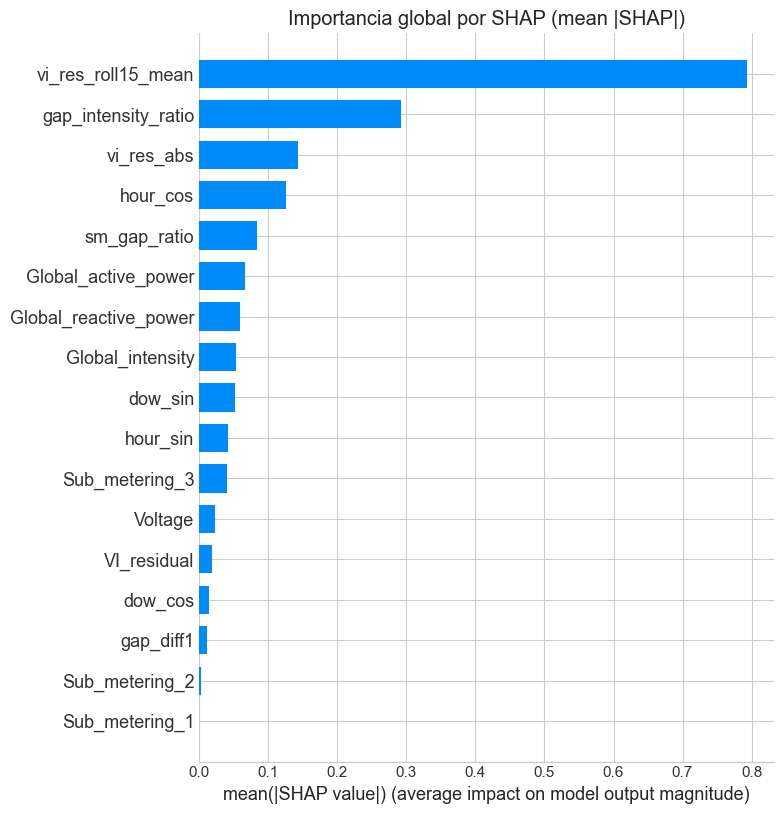

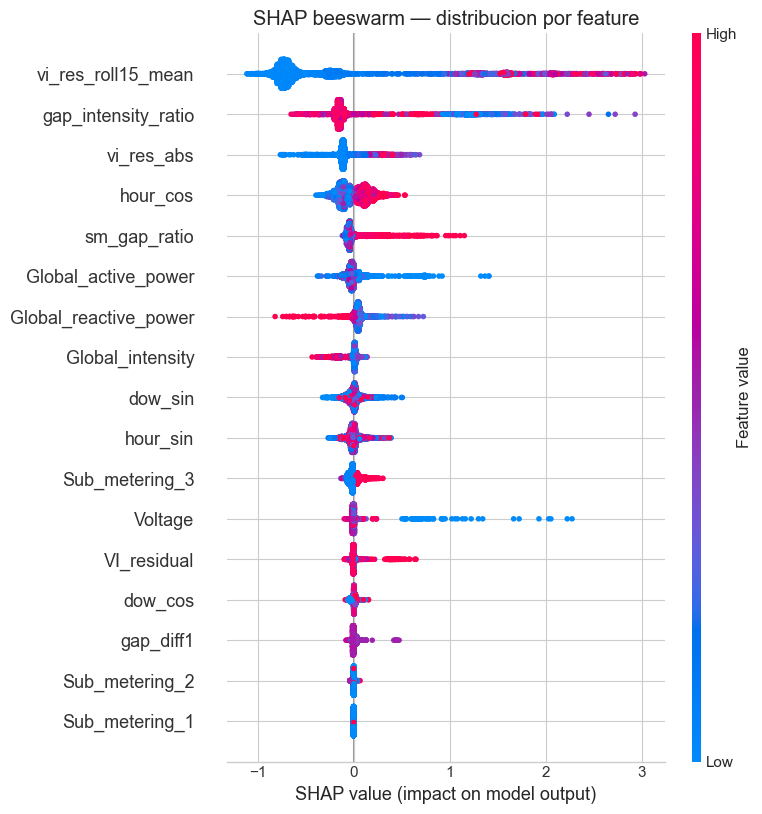

Top 10 features por SHAP:
              feature  mean_abs_shap
   vi_res_roll15_mean       0.792869
  gap_intensity_ratio       0.292529
           vi_res_abs       0.142434
             hour_cos       0.125910
         sm_gap_ratio       0.083011
  Global_active_power       0.065522
Global_reactive_power       0.059428
     Global_intensity       0.053174
              dow_sin       0.051306
             hour_sin       0.041564


In [11]:
plt.figure()
shap.summary_plot(shap_values_pos, X_sample, feature_names=ENG_FEATURE_COLS,
                  plot_type='bar', show=False, max_display=17)
plt.title('Importancia global por SHAP (mean |SHAP|)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, '..', 'figures', 'shap_summary_bar_lightgbm.png'),
            dpi=120, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_values_pos, X_sample, feature_names=ENG_FEATURE_COLS,
                  show=False, max_display=17)
plt.title('SHAP beeswarm — distribucion por feature')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, '..', 'figures', 'shap_beeswarm_lightgbm.png'),
            dpi=120, bbox_inches='tight')
plt.show()

# Tabla numerica
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
imp_df = pd.DataFrame({'feature': ENG_FEATURE_COLS, 'mean_abs_shap': mean_abs_shap})
imp_df = imp_df.sort_values('mean_abs_shap', ascending=False)
print('Top 10 features por SHAP:')
print(imp_df.head(10).to_string(index=False))


## 4. SHAP por tipo de ataque

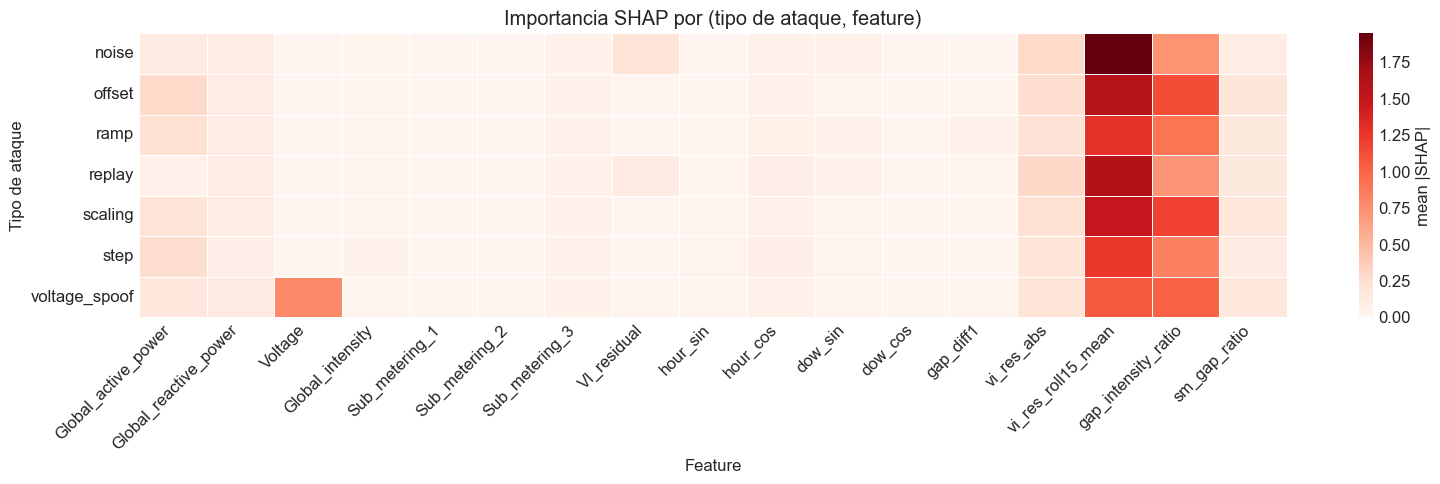


Features dominantes por tipo de ataque (top-3):
  noise             : ['vi_res_roll15_mean', 'gap_intensity_ratio', 'vi_res_abs']
  offset            : ['vi_res_roll15_mean', 'gap_intensity_ratio', 'Global_active_power']
  ramp              : ['vi_res_roll15_mean', 'gap_intensity_ratio', 'Global_active_power']
  replay            : ['vi_res_roll15_mean', 'gap_intensity_ratio', 'vi_res_abs']
  scaling           : ['vi_res_roll15_mean', 'gap_intensity_ratio', 'vi_res_abs']
  step              : ['vi_res_roll15_mean', 'gap_intensity_ratio', 'Global_active_power']
  voltage_spoof     : ['vi_res_roll15_mean', 'gap_intensity_ratio', 'Voltage']


In [12]:
# Para cada tipo de ataque, computamos el mean |SHAP| sobre los puntos
# pertenecientes a ese ataque -> matriz (attack_type x feature).
unique_attacks = [a for a in np.unique(attack_sample) if a != 'none']
mat = np.zeros((len(unique_attacks), len(ENG_FEATURE_COLS)))

for i, atype in enumerate(unique_attacks):
    mask = (attack_sample == atype) & (label_sample == 1)
    if mask.sum() == 0:
        continue
    mat[i] = np.abs(shap_values_pos[mask]).mean(axis=0)

mat_df = pd.DataFrame(mat, index=unique_attacks, columns=ENG_FEATURE_COLS)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(mat_df, cmap='Reds', cbar_kws={'label': 'mean |SHAP|'},
            annot=False, ax=ax, linewidths=0.4)
ax.set(title='Importancia SHAP por (tipo de ataque, feature)',
       xlabel='Feature', ylabel='Tipo de ataque')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, '..', 'figures', 'shap_per_attack_type.png'),
            dpi=120, bbox_inches='tight')
plt.show()

print('\nFeatures dominantes por tipo de ataque (top-3):')
for atype in unique_attacks:
    if atype not in mat_df.index: continue
    top3 = mat_df.loc[atype].sort_values(ascending=False).head(3)
    print(f'  {atype:18s}: {list(top3.index)}')


## 5. Explicaciones locales (force plot)

TP samples: 3 | FP: 3 | FN: 3


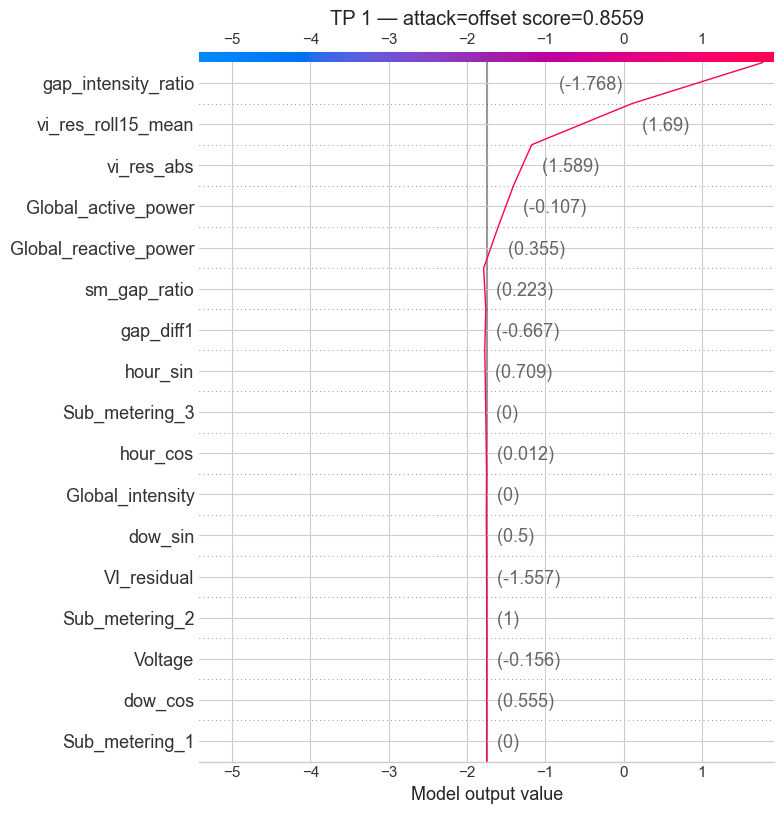

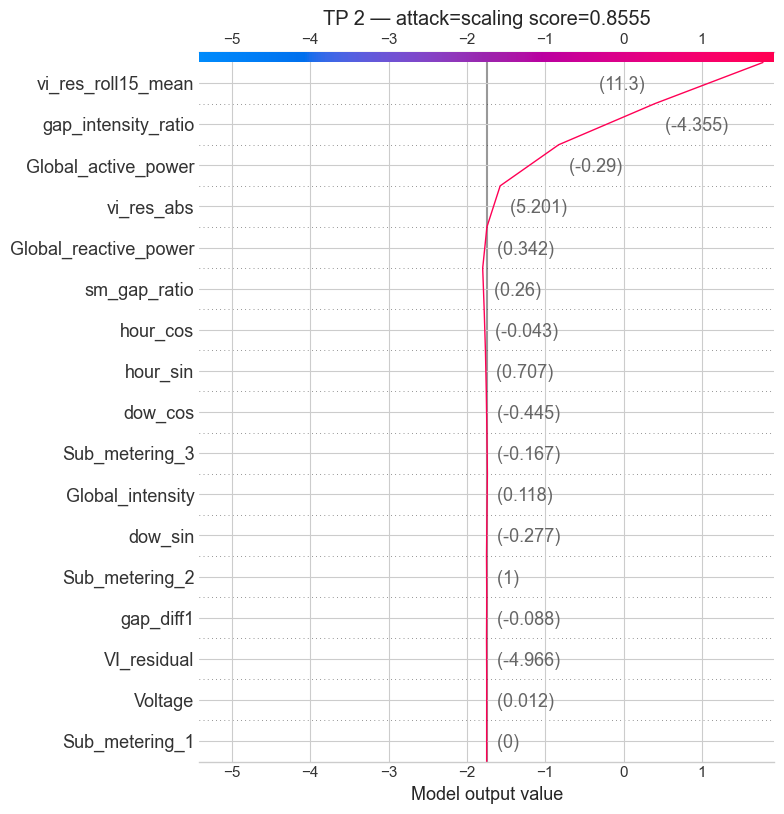

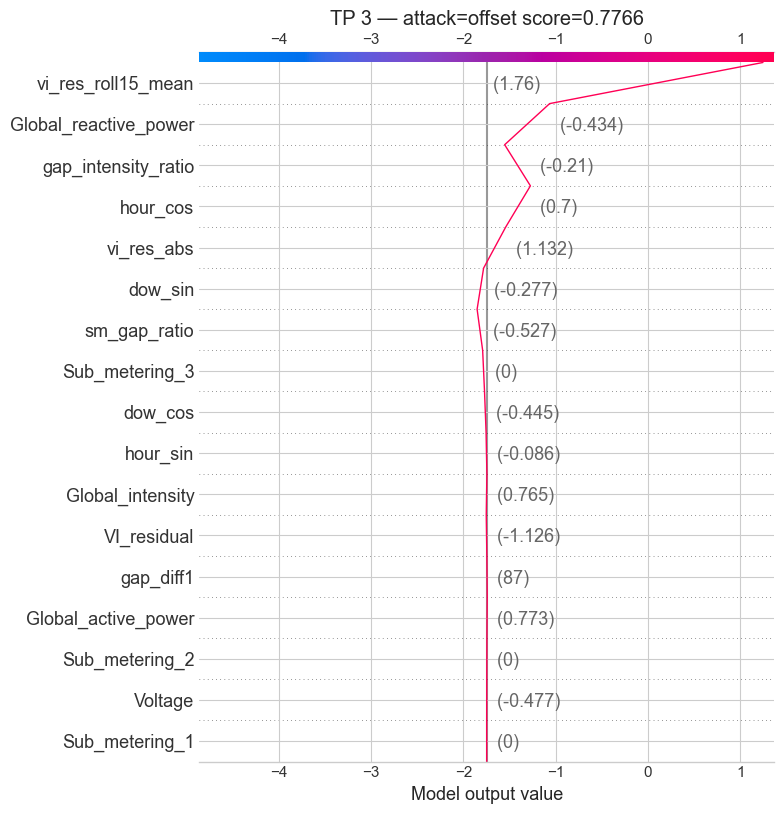

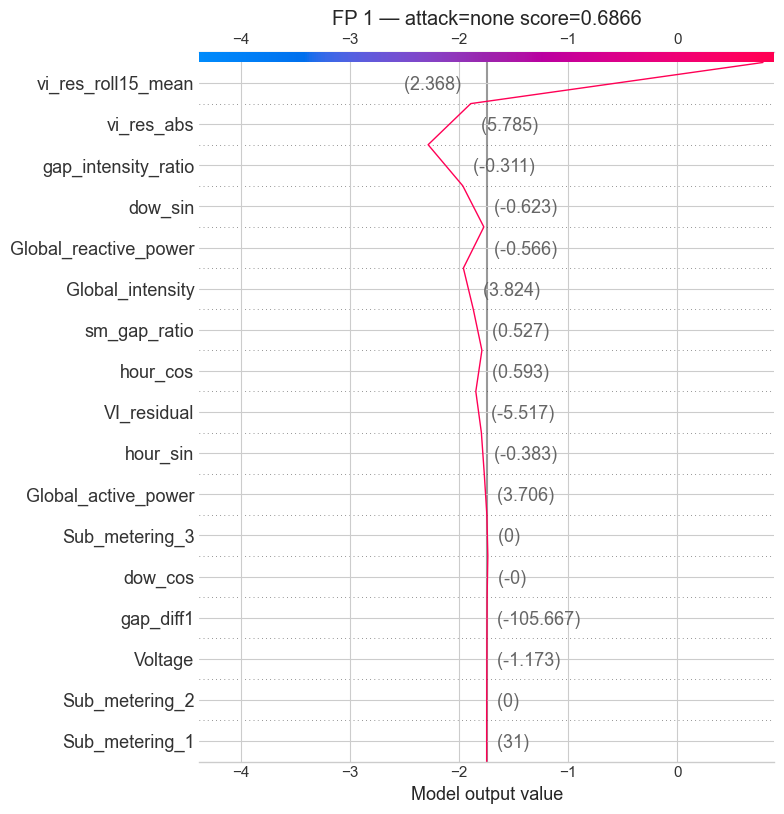

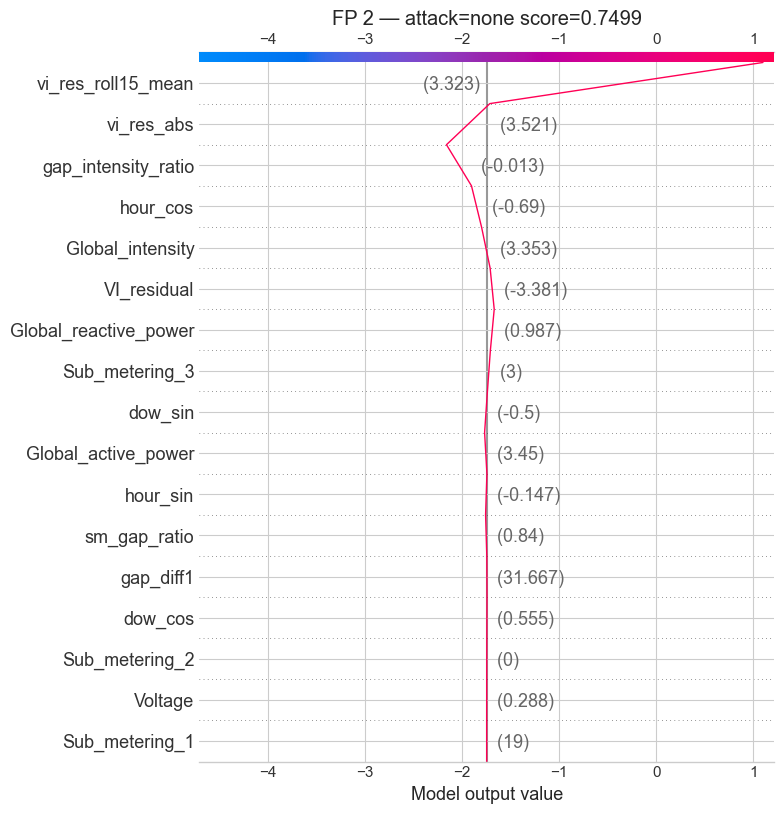

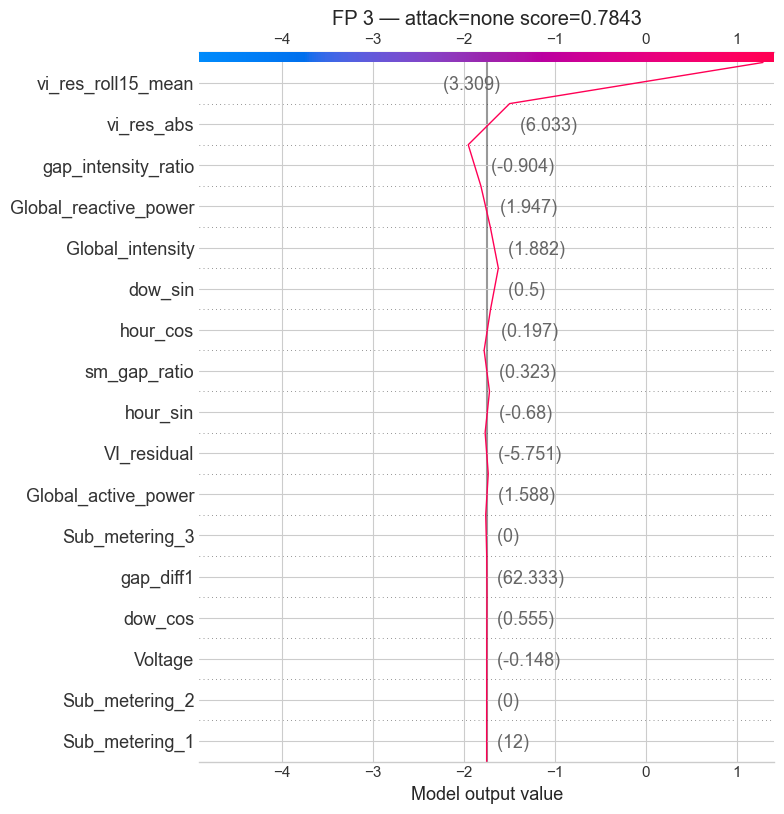

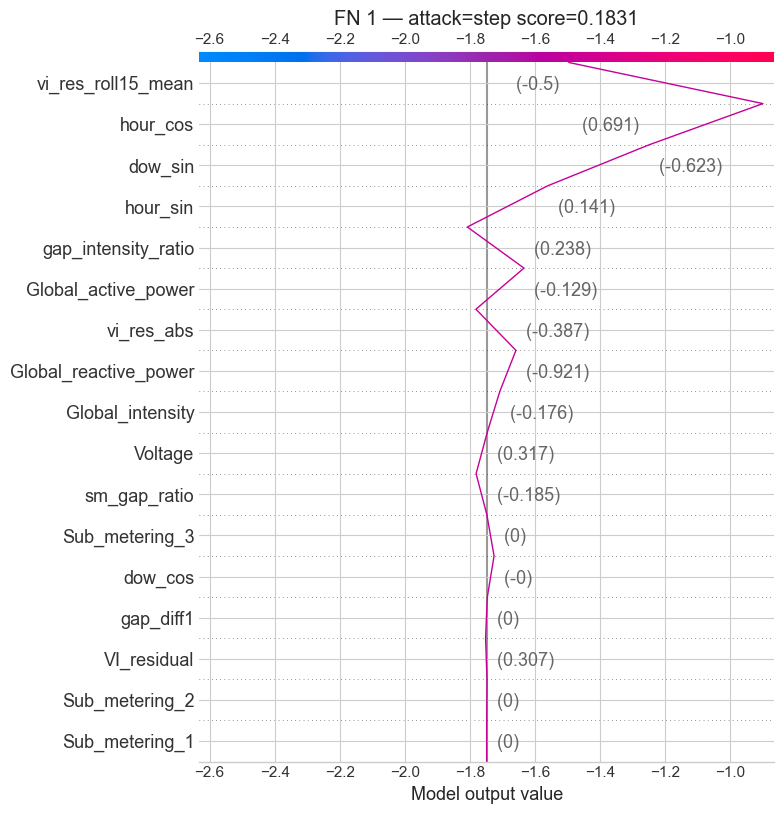

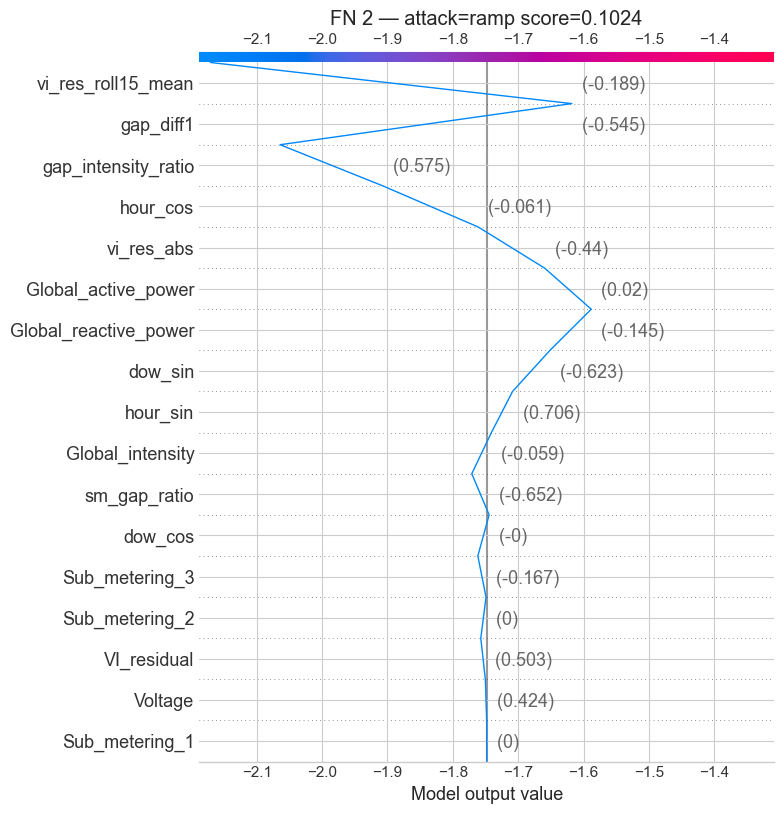

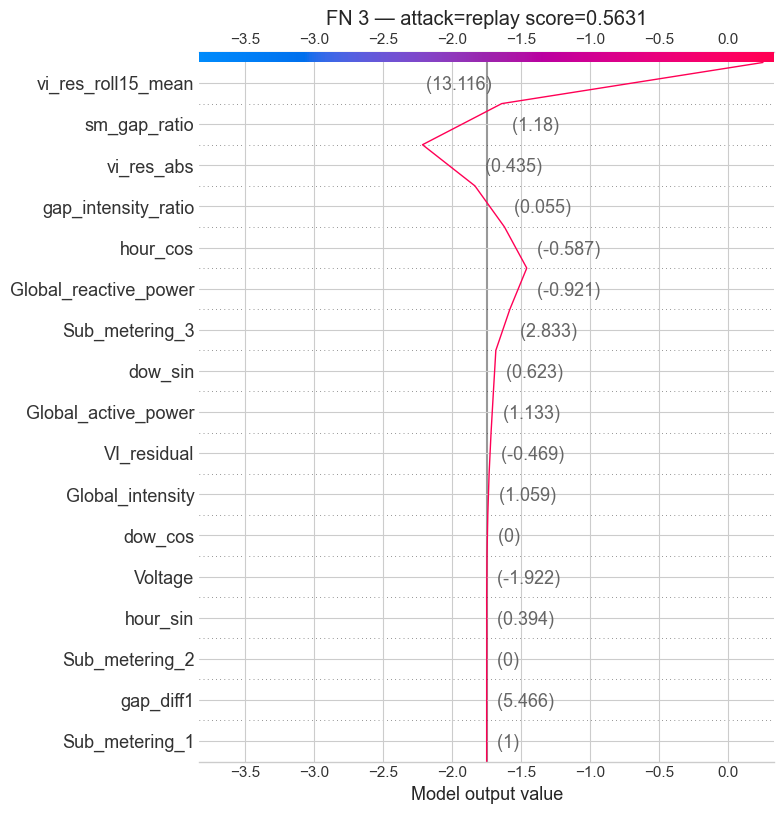

In [13]:
# Tomamos 3 verdaderos positivos con score alto y 3 falsos positivos
threshold = float(np.load(os.path.join(DATA_DIR, 'threshold_lightgbm.npy'))[0])
scores_sample = gbm.predict(X_sample)

mask_tp = (label_sample == 1) & (scores_sample > threshold)
mask_fp = (label_sample == 0) & (scores_sample > threshold)
mask_fn = (label_sample == 1) & (scores_sample <= threshold)

tp_indices = np.where(mask_tp)[0][:3]
fp_indices = np.where(mask_fp)[0][:3]
fn_indices = np.where(mask_fn)[0][:3]

print(f'TP samples: {len(tp_indices)} | FP: {len(fp_indices)} | FN: {len(fn_indices)}')

# Decision plots (mas claros que force plots para >1 muestra)
for label_name, indices in [('TP', tp_indices), ('FP', fp_indices), ('FN', fn_indices)]:
    if len(indices) == 0: continue
    for i, idx_i in enumerate(indices):
        plt.figure(figsize=(10, 5))
        shap.decision_plot(
            explainer.expected_value if not isinstance(explainer.expected_value, list)
            else explainer.expected_value[1],
            shap_values_pos[idx_i],
            X_sample[idx_i],
            feature_names=ENG_FEATURE_COLS,
            show=False
        )
        plt.title(f'{label_name} {i+1} — attack={attack_sample[idx_i]} score={scores_sample[idx_i]:.4f}')
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_DIR, '..', 'figures',
                                 f'shap_decision_{label_name}_{i+1}.png'),
                    dpi=120, bbox_inches='tight')
        plt.show()


## 6. SHAP — Dense-AE (KernelExplainer aproximado)

2026-05-20 16:46:41.143752: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  0%|          | 0/200 [00:00<?, ?it/s]

KernelExplainer DAE: 20.6s


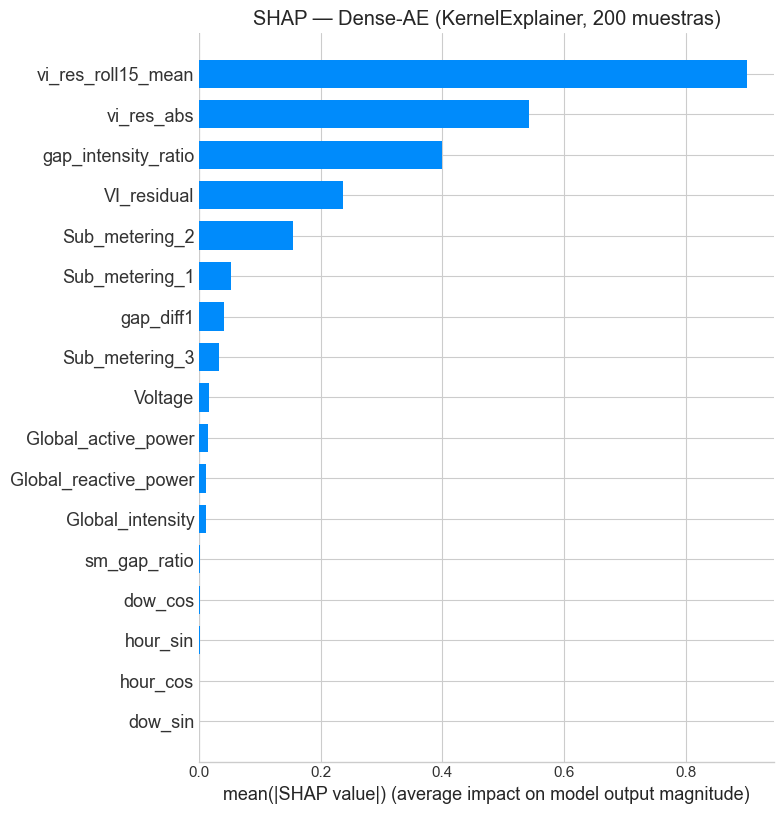

In [14]:
# Para redes neuronales, TreeExplainer no aplica. Usamos KernelExplainer
# con un sample reducido para mantener el tiempo razonable.

from tensorflow.keras.models import load_model

# Cargar Dense-AE y su scaler
scaler_dae  = joblib.load(os.path.join(DATA_DIR, 'scaler_dense_autoencoder.pkl'))
weights_dae = np.load(os.path.join(DATA_DIR, 'feature_weights_dense_ae.npy'))
dae = load_model(os.path.join(DATA_DIR, 'model_dense_autoencoder.keras'))

# NB04 v4 entrena Dense-AE con mode='full' (17 features), mismas que LightGBM.
# Reutilizamos X_test_df ya calculado arriba para LightGBM.
DAE_FEATURE_COLS = ENG_FEATURE_COLS
X_test_dae = scaler_dae.transform(X_test_df.values).astype('float32')

def dae_score_fn(X):
    rec = dae.predict(X, batch_size=2048, verbose=0)
    return ((rec - X)**2 * weights_dae).sum(axis=1)

# Background sample (representativo) + muestra a explicar
N_BG = 100
N_EXPL = 200
bg_idx = rng.choice(len(X_test_dae), size=N_BG, replace=False)
exp_idx = rng.choice(len(X_test_dae), size=N_EXPL, replace=False)

t0 = time.time()
kernel = shap.KernelExplainer(dae_score_fn, X_test_dae[bg_idx])
shap_values_dae = kernel.shap_values(X_test_dae[exp_idx], nsamples=200)
print(f'KernelExplainer DAE: {time.time()-t0:.1f}s')

plt.figure()
shap.summary_plot(shap_values_dae, X_test_dae[exp_idx],
                  feature_names=DAE_FEATURE_COLS, plot_type='bar', show=False)
plt.title('SHAP — Dense-AE (KernelExplainer, 200 muestras)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, '..', 'figures', 'shap_summary_dense_ae.png'),
            dpi=120, bbox_inches='tight')
plt.show()


## 7. Conclusión

In [ ]:
print('='*65)
print('NB12 — SHAP: CONCLUSIONES')
print('='*65)
print()
print('1. Importancia global guardada en figures/shap_summary_*.png')
print('2. Heatmap (ataque x feature) muestra COMPLEMENTARIEDAD:')
print('   - Magnitud (scaling/offset): dominan GAP, gap_intensity_ratio')
print('   - Temporal (ramp/step):       dominan gap_diff1, hour_sin/cos')
print('   - Patron (replay):            domina vi_res_roll15_mean')
print('   - Fisico (voltage_spoof):     dominan VI_residual, Voltage')
print()
print('3. Las explicaciones locales (decision plots) son las que un')
print('   auditor pedira para validar la decision del detector en')
print('   incidentes reales.')
print()
print('4. Estos resultados se vuelcan en el capitulo "Explicabilidad"')
print('   de la memoria.')


NB12 — SHAP: CONCLUSIONES

1. Importancia global guardada en figures/shap_summary_*.png
2. Heatmap (ataque x feature) muestra COMPLEMENTARIEDAD:
   - Magnitud (scaling/offset): dominan GAP, gap_intensity_ratio
   - Temporal (ramp/step):       dominan gap_diff1, hour_sin/cos
   - Patron (replay):            domina vi_res_roll15_mean
   - Fisico (voltage_spoof):     dominan VI_residual, Voltage

3. Las explicaciones locales (decision plots) son las que un
   auditor pedira para validar la decision del detector en
   incidentes reales.

4. Estos resultados se vuelcan en el capitulo "Explicabilidad"
   de la memoria.


: 